In [1]:
!pip install deepface opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.6 MB/s eta 0:00:00


26-03-13 05:39:28 - Directory /root/.deepface has been created
26-03-13 05:39:28 - Directory /root/.deepface/weights has been created


<IPython.core.display.Javascript object>

웹캠 권한을 허용해 주세요! 2초 뒤에 찰칵 찍힙니다 📸
사진 촬영 완료! 분석을 시작합니다...
26-03-13 05:39:33 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5
100%|██████████| 5.98M/5.98M [00:00<00:00, 472MB/s]



[분석 결과]
👉 가장 지배적인 감정: happy
 - angry: 0.00%
 - disgust: 0.00%
 - fear: 0.70%
 - happy: 64.99%
 - sad: 22.97%
 - surprise: 0.00%
 - neutral: 11.34%


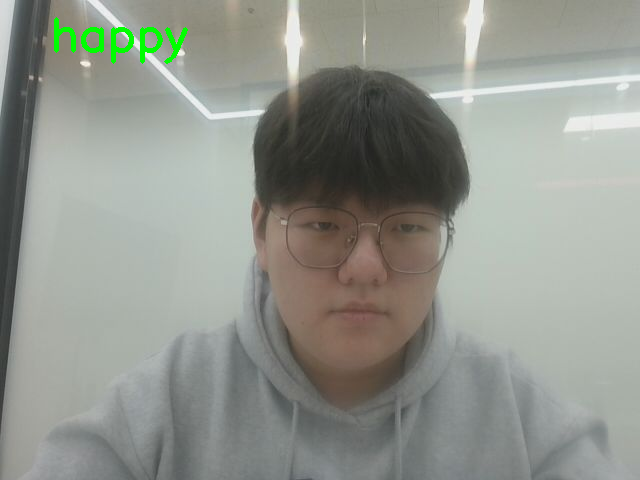

In [2]:
# # 1. 필요한 라이브러리 설치 (코랩 셀에서 실행)
# !pip install deepface opencv-python

# ---------------------------------------------------
# 2. 웹캠 캡처 및 분석 코드 (새 셀에 넣고 실행)
from IPython.display import display, Javascript
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow # 코랩 전용 이미지 출력 함수
from base64 import b64decode
import cv2
from deepface import DeepFace

def take_photo_and_analyze(filename='photo.jpg', quality=0.8):
  # 자바스크립트로 브라우저 웹캠 접근 권한 요청 및 화면 캡처
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // 결과 캡처를 위해 대기 (화면 클릭 등의 인터랙션을 넣을 수도 있음)
      await new Promise(resolve => setTimeout(resolve, 2000)); // 2초 뒤 자동 캡처

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)

  print("웹캠 권한을 허용해 주세요! 2초 뒤에 찰칵 찍힙니다 📸")

  try:
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
      f.write(binary)
    print("사진 촬영 완료! 분석을 시작합니다...")
  except Exception as e:
    print("웹캠 접근 실패. 권한을 확인해주세요:", e)
    return

  # --- 여기서부터 DeepFace 분석 ---
  img = cv2.imread(filename)

  try:
      # DeepFace로 감정 분석
      result = DeepFace.analyze(img, actions=['emotion'], enforce_detection=False)
      dominant_emotion = result[0]['dominant_emotion']

      # 사진 위에 결과 텍스트 쓰기
      cv2.putText(img, dominant_emotion, (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 3)

      print("\n[분석 결과]")
      print(f"👉 가장 지배적인 감정: {dominant_emotion}")

      # 세부 감정 수치 출력
      for emotion, score in result[0]['emotion'].items():
          print(f" - {emotion}: {score:.2f}%")

  except Exception as e:
      print("얼굴 분석 에러:", e)

  # cv2.imshow() 대신 코랩 전용 함수로 화면에 이미지 띄우기
  cv2_imshow(img)

# 함수 실행
take_photo_and_analyze()

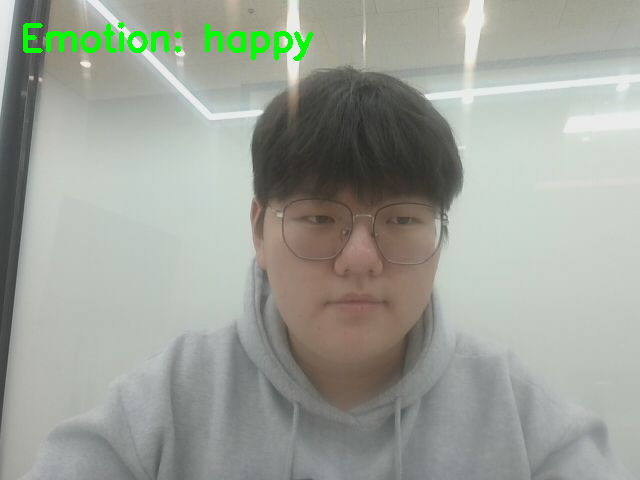

카메라 연결 지연 중... 잠시 대기합니다.
카메라 연결 지연 중... 잠시 대기합니다.
카메라 연결 지연 중... 잠시 대기합니다.
카메라 연결 지연 중... 잠시 대기합니다.
카메라 연결 지연 중... 잠시 대기합니다.
카메라 연결 지연 중... 잠시 대기합니다.
분석을 종료합니다. (정지 버튼 누름)


In [3]:
import cv2
import numpy as np
import time
from IPython.display import display, Javascript, clear_output
from google.colab.output import eval_js
from base64 import b64decode
from deepface import DeepFace
from google.colab.patches import cv2_imshow

def start_webcam():
  js = Javascript('''
    window.video = document.createElement('video');
    window.video.style.display = 'none';
    window.canvas = document.createElement('canvas');
    navigator.mediaDevices.getUserMedia({video: true}).then(stream => {
        window.stream = stream;
        window.video.srcObject = stream;
        window.video.play();
    }).catch(e => console.error("카메라 에러:", e));
  ''')
  display(js)

def get_frame():
  try:
      data = eval_js('''
        if (!window.stream) throw new Error("Stream not ready");
        window.canvas.width = window.video.videoWidth;
        window.canvas.height = window.video.videoHeight;
        window.canvas.getContext('2d').drawImage(window.video, 0, 0);
        window.canvas.toDataURL('image/jpeg', 0.8);
      ''')
      binary = b64decode(data.split(',')[1])
      image = np.asarray(bytearray(binary), dtype="uint8")
      return cv2.imdecode(image, cv2.IMREAD_COLOR)
  except Exception as e:
      return None

def stop_webcam():
  try:
      eval_js('window.stream.getVideoTracks()[0].stop();')
  except:
      pass

# 메인 실행부
start_webcam()
print("웹캠 로딩 중... (3초 대기 ⏳)")
time.sleep(3)

print("✅ 실시간 분석 시작! (과부하 방지를 위해 0.5초 간격으로 분석합니다)")
time.sleep(1)

try:
    while True:
        frame = get_frame()
        # 프레임이 깨지거나 잠깐 끊기면 에러 내지 않고 1초 대기 후 다시 시도
        if frame is None or frame.shape[0] == 0:
            print("카메라 연결 지연 중... 잠시 대기합니다.")
            time.sleep(1)
            continue

        try:
            # DeepFace 감정 분석
            result = DeepFace.analyze(frame, actions=['emotion'], enforce_detection=False)
            dominant_emotion = result[0]['dominant_emotion']

            # 화면에 글씨 쓰기
            cv2.putText(frame, f"Emotion: {dominant_emotion}", (20, 50),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)
        except:
            pass

        # 화면 갱신
        clear_output(wait=True)
        cv2_imshow(frame)

        # ⭐️ 핵심: 서버와 브라우저가 과부하 걸리지 않게 0.5초 쉬어주기
        time.sleep(0.5)

except KeyboardInterrupt:
    print("분석을 종료합니다. (정지 버튼 누름)")
finally:
    stop_webcam()

<IPython.core.display.Javascript object>

버튼이 보이지 않으면 이 셀을 한 번만 다시 실행하세요.
'카메라 켜기'를 누르면 시작되고, '카메라 끄기'를 누르면 종료됩니다.
neutral: 30.7% / fear: 25.2% / sad: 24.1%


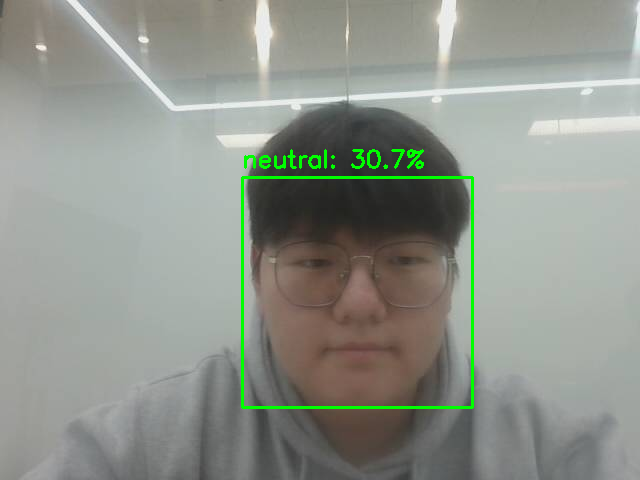

sad: 37.1% / neutral: 35.5% / fear: 17.8%


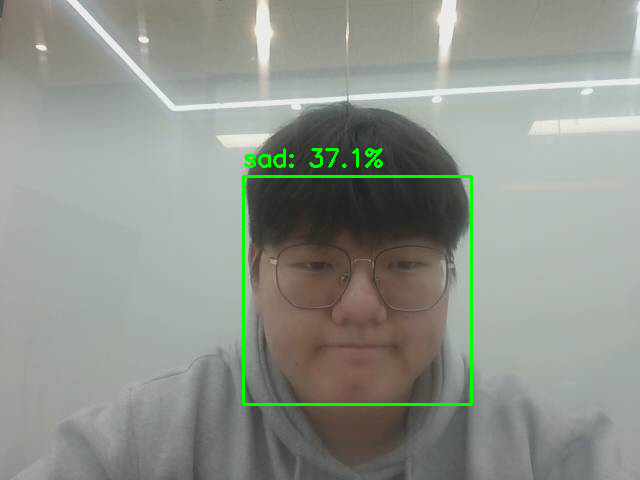

fear: 93.8% / sad: 4.9% / neutral: 1.3%


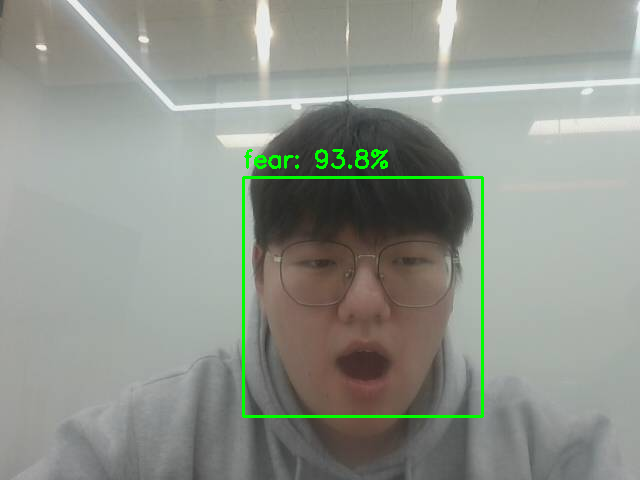

fear: 41.8% / happy: 34.9% / neutral: 22.4%


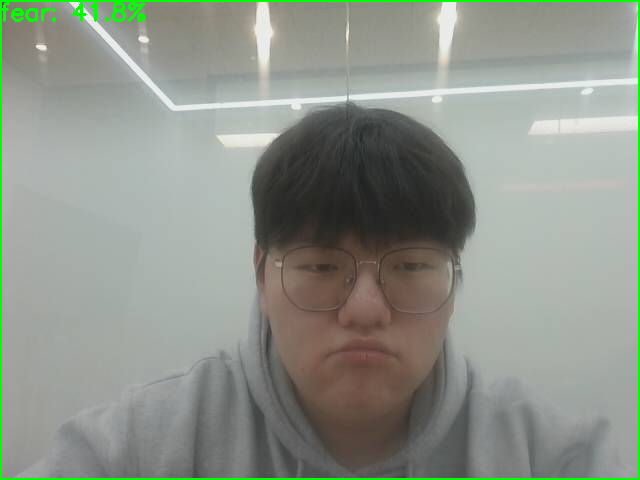

angry: 58.9% / sad: 20.9% / fear: 11.8%


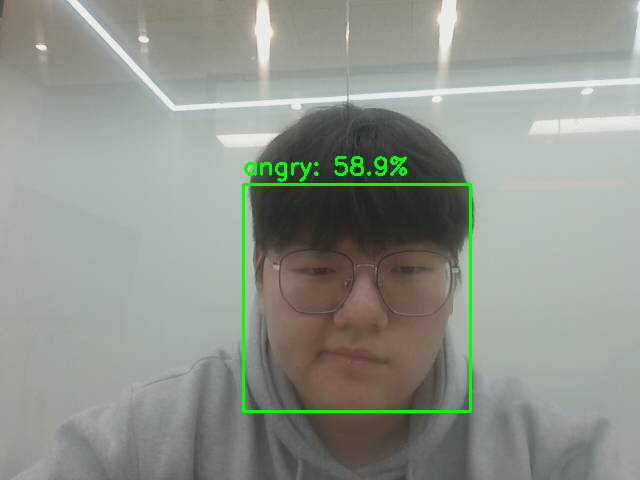

angry: 47.0% / fear: 28.1% / disgust: 13.1%


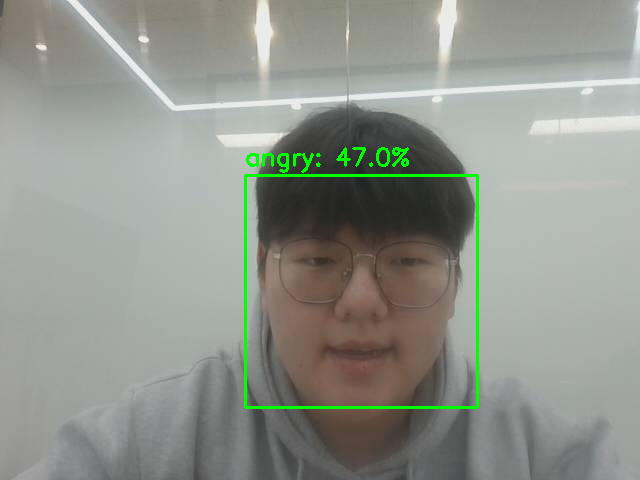

카메라가 종료되어 분석을 끝냅니다.


In [7]:
import base64
import cv2
import numpy as np
import time
from deepface import DeepFace
from google.colab import output
from IPython.display import display, Javascript, HTML
from google.colab.patches import cv2_imshow

# ---------------------------------
# 웹캠 UI 생성
# ---------------------------------
def init_camera():
    display(Javascript(r'''
    async function setupCameraUI() {
      if (document.getElementById("camera-root")) return;

      const root = document.createElement("div");
      root.id = "camera-root";
      root.style.border = "1px solid #ccc";
      root.style.padding = "12px";
      root.style.margin = "12px 0";

      const btnStart = document.createElement("button");
      btnStart.innerText = "카메라 켜기";
      btnStart.style.marginRight = "8px";

      const btnStop = document.createElement("button");
      btnStop.innerText = "카메라 끄기";

      const status = document.createElement("div");
      status.id = "camera-status";
      status.style.marginTop = "8px";
      status.innerText = "대기 중";

      const video = document.createElement("video");
      video.id = "camera-video";
      video.autoplay = true;
      video.playsInline = true;
      video.width = 480;
      video.height = 360;
      video.style.display = "block";
      video.style.marginTop = "10px";
      video.style.border = "1px solid #999";

      const canvas = document.createElement("canvas");
      canvas.id = "camera-canvas";
      canvas.style.display = "none";

      root.appendChild(btnStart);
      root.appendChild(btnStop);
      root.appendChild(status);
      root.appendChild(video);
      document.body.appendChild(root);
      document.body.appendChild(canvas);

      window.cameraState = "idle";   // idle, running, stopped
      window.cameraStream = null;

      btnStart.onclick = async () => {
        if (window.cameraState === "running") return;

        try {
          const stream = await navigator.mediaDevices.getUserMedia({
            video: true,
            audio: false
          });

          const videoEl = document.getElementById("camera-video");
          videoEl.srcObject = stream;
          await videoEl.play();

          window.cameraStream = stream;
          window.cameraState = "running";
          document.getElementById("camera-status").innerText = "카메라 실행 중";
        } catch (e) {
          document.getElementById("camera-status").innerText = "웹캠 권한 오류: " + e;
          window.cameraState = "idle";
        }
      };

      btnStop.onclick = () => {
        if (window.cameraStream) {
          window.cameraStream.getTracks().forEach(t => t.stop());
          window.cameraStream = null;
        }
        const videoEl = document.getElementById("camera-video");
        if (videoEl) videoEl.srcObject = null;
        window.cameraState = "stopped";
        document.getElementById("camera-status").innerText = "카메라 종료됨";
      };
    }

    setupCameraUI();
    '''))


# ---------------------------------
# 상태 확인
# ---------------------------------
def get_camera_state():
    return output.eval_js("window.cameraState || 'idle'")


# ---------------------------------
# 프레임 캡처
# ---------------------------------
def get_frame_from_browser(quality=0.7):
    js = r'''
    async function captureFrame(q) {
      const state = window.cameraState || "idle";
      if (state !== "running") return null;

      const video = document.getElementById("camera-video");
      const canvas = document.getElementById("camera-canvas");
      if (!video || !canvas) return null;
      if (video.videoWidth === 0 || video.videoHeight === 0) return null;

      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      const ctx = canvas.getContext("2d");
      ctx.drawImage(video, 0, 0, canvas.width, canvas.height);

      return canvas.toDataURL("image/jpeg", q);
    }
    '''
    output.eval_js(js)
    return output.eval_js(f"captureFrame({quality})")


# ---------------------------------
# base64 -> OpenCV 이미지
# ---------------------------------
def data_url_to_cv2_image(data_url):
    encoded = data_url.split(",")[1]
    binary = base64.b64decode(encoded)
    img_np = np.frombuffer(binary, dtype=np.uint8)
    img = cv2.imdecode(img_np, cv2.IMREAD_COLOR)
    return img


# ---------------------------------
# 감정 분석
# ---------------------------------
def analyze_emotion(frame):
    annotated = frame.copy()

    try:
        result = DeepFace.analyze(
            img_path=frame,
            actions=['emotion'],
            enforce_detection=False,
            detector_backend='opencv',
            silent=True
        )

        if isinstance(result, dict):
            result = [result]

        if not result:
            return annotated, "No face detected"

        texts = []

        for face in result:
            region = face.get("region", {})
            x = int(region.get("x", 0))
            y = int(region.get("y", 0))
            w = int(region.get("w", 0))
            h = int(region.get("h", 0))

            dominant = face.get("dominant_emotion", "unknown")
            emotions = face.get("emotion", {})
            score = float(emotions.get(dominant, 0.0))

            if w > 0 and h > 0:
                cv2.rectangle(annotated, (x, y), (x+w, y+h), (0, 255, 0), 2)
                cv2.putText(
                    annotated,
                    f"{dominant}: {score:.1f}%",
                    (x, max(20, y-10)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    (0, 255, 0),
                    2
                )

            top3 = sorted(emotions.items(), key=lambda kv: kv[1], reverse=True)[:3]
            texts.append(" / ".join([f"{k}: {v:.1f}%" for k, v in top3]))

        return annotated, "\n".join(texts)

    except Exception as e:
        return annotated, f"Analysis error: {e}"


# ---------------------------------
# 메인 루프
# ---------------------------------
def run_realtime_emotion_analysis(sleep_sec=0.3, show_frame_every=5):
    init_camera()

    print("버튼이 보이지 않으면 이 셀을 한 번만 다시 실행하세요.")
    print("'카메라 켜기'를 누르면 시작되고, '카메라 끄기'를 누르면 종료됩니다.")

    frame_idx = 0

    while True:
        state = get_camera_state()

        if state == "stopped":
            print("카메라가 종료되어 분석을 끝냅니다.")
            break

        if state != "running":
            time.sleep(0.3)
            continue

        data_url = get_frame_from_browser()
        if data_url is None:
            time.sleep(0.1)
            continue

        frame = data_url_to_cv2_image(data_url)
        if frame is None:
            time.sleep(0.1)
            continue

        annotated, result_text = analyze_emotion(frame)

        frame_idx += 1
        if frame_idx % show_frame_every == 0:
            print("=" * 50)
            print(result_text)
            cv2_imshow(annotated)

        time.sleep(sleep_sec)


run_realtime_emotion_analysis(sleep_sec=0.3, show_frame_every=10)